# Waveguide Width Sweep for Tidy3D MODE

这个 notebook 用于对 silicon strip waveguide 的 width 做低成本 MODE sweep。

- Height 固定为 `0.22 um`
- Cladding 为 `SiO2`
- 中心 wavelength 为 `1.55 um`
- 扫描 widths = `[0.40, 0.45, 0.50, 0.55, 0.60] um`

输出内容：

- `waveguide_width_sweep_results.csv`
- `neff_vs_width.png`
- 每个 width 对应的云端 `.hdf5` 结果文件

In [1]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tidy3d as td
import tidy3d.web as web
from tidy3d.constants import C_0

In [2]:
# =========================
# Basic sweep configuration
# =========================
WIDTHS_UM = [0.40, 0.45, 0.50, 0.55, 0.60]
CORE_THICKNESS_UM = 0.22
WAVELENGTH_UM = 1.55

CORE_N = 3.48
CLAD_N = 1.44

# Keep the MODE simulation region modest to reduce cost.
SIM_SIZE_Y_UM = 4.0
SIM_SIZE_Z_UM = 3.0
MIN_STEPS_PER_WVL = 20
NUM_MODES = 4

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "mode_width_sweep"
CSV_PATH = PROJECT_ROOT / "waveguide_width_sweep_results.csv"
PLOT_PATH = PROJECT_ROOT / "neff_vs_width.png"

DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"Current working directory: {PROJECT_ROOT}")
print(f"CSV will be saved to: {CSV_PATH}")
print(f"Plot will be saved to: {PLOT_PATH}")

Current working directory: /Users/luojiahua/Library/CloudStorage/OneDrive-UW/Slides/Slides/EE588/project/tidy3d_awg_project
CSV will be saved to: /Users/luojiahua/Library/CloudStorage/OneDrive-UW/Slides/Slides/EE588/project/tidy3d_awg_project/waveguide_width_sweep_results.csv
Plot will be saved to: /Users/luojiahua/Library/CloudStorage/OneDrive-UW/Slides/Slides/EE588/project/tidy3d_awg_project/neff_vs_width.png


In [3]:
def build_materials():
    """Define cladding and core materials."""
    clad_medium = td.Medium(
        name="SiO2_cladding",
        permittivity=CLAD_N**2,
    )
    core_medium = td.Medium(
        name="Silicon_core",
        permittivity=CORE_N**2,
    )
    return clad_medium, core_medium


def build_waveguide(width_um, core_medium):
    """Create an infinitely long strip waveguide along the x direction."""
    return td.Structure(
        geometry=td.Box(size=[td.inf, width_um, CORE_THICKNESS_UM]),
        name=f"silicon_waveguide_{width_um:.2f}um",
        medium=core_medium,
    )


def build_mode_simulation(width_um):
    """Create a low-cost MODE simulation for one waveguide width."""
    clad_medium, core_medium = build_materials()
    waveguide = build_waveguide(width_um, core_medium)
    freq0 = C_0 / WAVELENGTH_UM

    sim = td.ModeSimulation(
        plane=td.Box(size=[0, SIM_SIZE_Y_UM, SIM_SIZE_Z_UM]),
        freqs=[freq0],
        mode_spec=td.ModeSpec(
            num_modes=NUM_MODES,
            group_index_step=True,
        ),
        size=[0, SIM_SIZE_Y_UM, SIM_SIZE_Z_UM],
        boundary_spec=td.BoundarySpec(
            x=td.Boundary.pml(),
            y=td.Boundary.pml(),
            z=td.Boundary.pml(),
        ),
        grid_spec=td.GridSpec.auto(
            min_steps_per_wvl=MIN_STEPS_PER_WVL,
            wavelength=WAVELENGTH_UM,
        ),
        medium=clad_medium,
        structures=[waveguide],
    )
    return sim


def extract_mode_results(sim_data):
    """Extract fundamental-mode effective index and optional group index."""
    modes = sim_data.modes_raw

    # Explicitly extract effective index from np.real(modes.n_complex).
    n_eff_all = np.real(modes.n_complex)
    n_eff_0 = float(n_eff_all.values[0, 0])

    n_group_0 = None
    if hasattr(modes, "n_group") and modes.n_group is not None:
        try:
            n_group_0 = float(modes.n_group.values[0, 0])
        except Exception:
            n_group_0 = None
    elif hasattr(modes, "n_group_raw") and modes.n_group_raw is not None:
        try:
            n_group_0 = float(modes.n_group_raw.values[0, 0])
        except Exception:
            n_group_0 = None

    return modes, n_eff_0, n_group_0

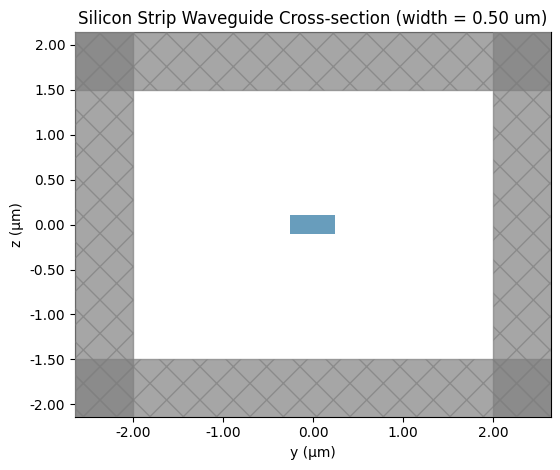

In [4]:
# Optional preview: inspect one cross-section before running the full sweep.
preview_width_um = 0.50
preview_sim = build_mode_simulation(preview_width_um)
preview_sim.plot(x=0)
plt.title(f"Silicon Strip Waveguide Cross-section (width = {preview_width_um:.2f} um)")
plt.show()

In [5]:
# Run the MODE sweep in the cloud.
# This step uses a small amount of Tidy3D credit.
rows = []
all_modes = {}

for width_um in WIDTHS_UM:
    sim = build_mode_simulation(width_um)
    width_label = f"{int(round(width_um * 1000)):03d}nm"
    task_name = f"silicon_strip_mode_width_{width_label}_1550nm"
    hdf5_path = DATA_DIR / f"waveguide_mode_width_{width_label}.hdf5"

    print(f"Running MODE sweep for width = {width_um:.2f} um")
    print(f"Task name: {task_name}")

    sim_data = web.run(
        sim,
        task_name=task_name,
        path=str(hdf5_path),
    )

    modes, n_eff_0, n_group_0 = extract_mode_results(sim_data)
    all_modes[width_um] = modes

    print("modes_raw extracted successfully")
    print(f"Fundamental mode n_eff = {n_eff_0:.6f}")
    if n_group_0 is not None:
        print(f"Fundamental mode n_group = {n_group_0:.6f}")
    else:
        print("Fundamental mode n_group not available in this result")
    print()

    rows.append(
        {
            "width_um": width_um,
            "height_um": CORE_THICKNESS_UM,
            "wavelength_um": WAVELENGTH_UM,
            "n_eff_mode0": n_eff_0,
            "n_group_mode0": n_group_0 if n_group_0 is not None else "",
            "task_name": task_name,
            "hdf5_path": str(hdf5_path.relative_to(PROJECT_ROOT)),
        }
    )

Running MODE sweep for width = 0.40 um
Task name: silicon_strip_mode_width_400nm_1550nm


16:56:12 PDT Loading simulation from local cache. View cached task using web UI 
             at                                                                 
             ]8;id=11880877;https://tidy3d.simulation.cloud/workbench?taskId=mos-19e30cec-ca92-4b76-8e76-6b041195d280\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=11880878;https://tidy3d.simulation.cloud/workbench?taskId=mos-19e30cec-ca92-4b76-8e76-6b041195d280\taskId]8;;\]8;id=11880877;https://tidy3d.simulation.cloud/workbench?taskId=mos-19e30cec-ca92-4b76-8e76-6b041195d280\=]8;;\]8;id=11880879;https://tidy3d.simulation.cloud/workbench?taskId=mos-19e30cec-ca92-4b76-8e76-6b041195d280\mos]8;;\]8;id=11880877;https://tidy3d.simulation.cloud/workbench?taskId=mos-19e30cec-ca92-4b76-8e76-6b041195d280\-19e30cec-ca92]8;;\
             ]8;id=11880877;https://tidy3d.simulation.cloud/workbench?taskId=mos-19e30cec-ca92-4b76-8e76-6b041195d280\-4b76-8e76-6b041195d280']8;;\.

modes_raw extracted successfully
Fundamental mode n_eff = 2.227509
Fundamental mode n_group = 4.244900

Running MODE sweep for width = 0.45 um
Task name: silicon_strip_mode_width_450nm_1550nm


             Loading simulation from local cache. View cached task using web UI 
             at                                                                 
             ]8;id=11880883;https://tidy3d.simulation.cloud/workbench?taskId=mos-4e540d88-f337-4b37-9dc0-414617002ee9\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=11880884;https://tidy3d.simulation.cloud/workbench?taskId=mos-4e540d88-f337-4b37-9dc0-414617002ee9\taskId]8;;\]8;id=11880883;https://tidy3d.simulation.cloud/workbench?taskId=mos-4e540d88-f337-4b37-9dc0-414617002ee9\=]8;;\]8;id=11880885;https://tidy3d.simulation.cloud/workbench?taskId=mos-4e540d88-f337-4b37-9dc0-414617002ee9\mos]8;;\]8;id=11880883;https://tidy3d.simulation.cloud/workbench?taskId=mos-4e540d88-f337-4b37-9dc0-414617002ee9\-4e540d88-f337]8;;\
             ]8;id=11880883;https://tidy3d.simulation.cloud/workbench?taskId=mos-4e540d88-f337-4b37-9dc0-414617002ee9\-4b37-9dc0-414617002ee9']8;;\.

modes_raw extracted successfully
Fundamental mode n_eff = 2.352712
Fundamental mode n_group = 4.144360

Running MODE sweep for width = 0.50 um
Task name: silicon_strip_mode_width_500nm_1550nm


...

modes_raw extracted successfully
Fundamental mode n_eff = 2.444580
Fundamental mode n_group = 4.051219

Running MODE sweep for width = 0.55 um
Task name: silicon_strip_mode_width_550nm_1550nm


             Loading simulation from local cache. View cached task using web UI 
             at                                                                 
             ]8;id=11880895;https://tidy3d.simulation.cloud/workbench?taskId=mos-8e066beb-3d7d-46c3-aea9-2a3cee8b808a\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=11880896;https://tidy3d.simulation.cloud/workbench?taskId=mos-8e066beb-3d7d-46c3-aea9-2a3cee8b808a\taskId]8;;\]8;id=11880895;https://tidy3d.simulation.cloud/workbench?taskId=mos-8e066beb-3d7d-46c3-aea9-2a3cee8b808a\=]8;;\]8;id=11880897;https://tidy3d.simulation.cloud/workbench?taskId=mos-8e066beb-3d7d-46c3-aea9-2a3cee8b808a\mos]8;;\]8;id=11880895;https://tidy3d.simulation.cloud/workbench?taskId=mos-8e066beb-3d7d-46c3-aea9-2a3cee8b808a\-8e066beb-3d7d]8;;\
             ]8;id=11880895;https://tidy3d.simulation.cloud/workbench?taskId=mos-8e066beb-3d7d-46c3-aea9-2a3cee8b808a\-46c3-aea9-2a3cee8b808a']8;;\.

modes_raw extracted successfully
Fundamental mode n_eff = 2.513132
Fundamental mode n_group = 3.974921

Running MODE sweep for width = 0.60 um
Task name: silicon_strip_mode_width_600nm_1550nm


             Loading simulation from local cache. View cached task using web UI 
             at                                                                 
             ]8;id=11880901;https://tidy3d.simulation.cloud/workbench?taskId=mos-51a40554-8ae3-4468-83e5-ca62e91da094\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=11880902;https://tidy3d.simulation.cloud/workbench?taskId=mos-51a40554-8ae3-4468-83e5-ca62e91da094\taskId]8;;\]8;id=11880901;https://tidy3d.simulation.cloud/workbench?taskId=mos-51a40554-8ae3-4468-83e5-ca62e91da094\=]8;;\]8;id=11880903;https://tidy3d.simulation.cloud/workbench?taskId=mos-51a40554-8ae3-4468-83e5-ca62e91da094\mos]8;;\]8;id=11880901;https://tidy3d.simulation.cloud/workbench?taskId=mos-51a40554-8ae3-4468-83e5-ca62e91da094\-51a40554-8ae3]8;;\
             ]8;id=11880901;https://tidy3d.simulation.cloud/workbench?taskId=mos-51a40554-8ae3-4468-83e5-ca62e91da094\-4468-83e5-ca62e91da094']8;;\.

modes_raw extracted successfully
Fundamental mode n_eff = 2.565697
Fundamental mode n_group = 3.914225



In [6]:
# Save CSV results.
with CSV_PATH.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=[
            "width_um",
            "height_um",
            "wavelength_um",
            "n_eff_mode0",
            "n_group_mode0",
            "task_name",
            "hdf5_path",
        ],
    )
    writer.writeheader()
    writer.writerows(rows)

print(f"Saved CSV to: {CSV_PATH}")

Saved CSV to: /Users/luojiahua/Library/CloudStorage/OneDrive-UW/Slides/Slides/EE588/project/tidy3d_awg_project/waveguide_width_sweep_results.csv


In [7]:
# Display the sweep table inside the notebook.
results_df = pd.DataFrame(rows)
results_df

,width_um,height_um,wavelength_um,n_eff_mode0,n_group_mode0,task_name,hdf5_path
0,0.40,0.22,1.55,2.227509,4.244900,silicon_strip_mode_width_400nm_1550nm,data/mode_width_sweep/waveguide_mode_width_400...
1,0.45,0.22,1.55,2.352712,4.144360,silicon_strip_mode_width_450nm_1550nm,data/mode_width_sweep/waveguide_mode_width_450...
2,0.50,0.22,1.55,2.444580,4.051219,silicon_strip_mode_width_500nm_1550nm,data/mode_width_sweep/waveguide_mode_width_500...
3,0.55,0.22,1.55,2.513132,3.974921,silicon_strip_mode_width_550nm_1550nm,data/mode_width_sweep/waveguide_mode_width_550...
4,0.60,0.22,1.55,2.565697,3.914225,silicon_strip_mode_width_600nm_1550nm,data/mode_width_sweep/waveguide_mode_width_600...


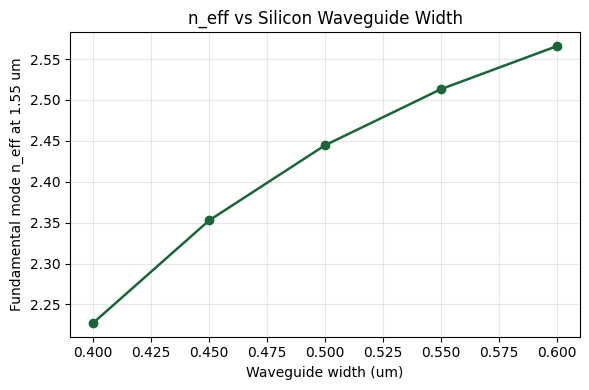

Saved plot to: /Users/luojiahua/Library/CloudStorage/OneDrive-UW/Slides/Slides/EE588/project/tidy3d_awg_project/neff_vs_width.png


In [8]:
# Plot n_eff vs waveguide width and save the figure.
plt.figure(figsize=(6, 4))
plt.plot(results_df["width_um"], results_df["n_eff_mode0"], marker="o", linewidth=1.8)
plt.xlabel("Waveguide width (um)")
plt.ylabel("Fundamental mode n_eff at 1.55 um")
plt.title("n_eff vs Silicon Waveguide Width")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=200)
plt.show()

print(f"Saved plot to: {PLOT_PATH}")

In [9]:
# Optional: inspect the modes_raw object for one width after the run.
inspect_width_um = 0.50
modes = all_modes[inspect_width_um]
print(type(modes))
print(modes)

<class 'tidy3d.components.data.monitor_data.ModeSolverData'>
ModeSolverData(
    Ex=<xarray.ScalarModeFieldDataArray (x: 1, y: 94, z: 69, f: 1, mode_index: 
4)> Size: 415kB
array([[[[[ 0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j]],

         [[ 0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j]],

         [[ 0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j]],

         ...,

         [[ 0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j,
...
            0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j]],

    